In [2]:
import pandas as pd
from utilsforecast.plotting import plot_series

## chapter  3.1

یک سری زمانی خام، پر از نویزها و اثرات گمراه‌کننده (مثل تورم، رشد جمعیت، تفاوت تعداد روزهای ماه و نوسانات متغیر) است. قبل از اینکه سری زمانی را به اجزایش (روند، فصل، باقی‌مانده) بشکنیم یا مدلی برای پیش‌بینی بسازیم، باید با تعدیل‌ها (Adjustments) و تبدیلات ریاضی (Transformations) داده را «تمیز و یکدست» کنیم تا مدل‌سازی دقیق‌تر و آسان‌تر شود.

----

-> Calendar adjustments = تعدیل تقویمی

-> Population adjustments = تعدیل جمعیتی یا سرانه

-> Inflation adjustments = تعدیل تورم

-> Mathematical transformations = تبدیلات ریاضی و باکس-کاکس

---

**Population Adjustment**

> اگر جمعیت بزرگ‌تر شود، خیلی از عددهای کل به‌صورت طبیعی زیاد می‌شوند؛ حتی اگر کیفیت خدمات یا رفاه هر فرد هیچ تغییری نکرده باشد.

> بنابراین برای مقایسه‌ی منصفانه در طول زمان یا بین مناطق، مقدار کل را بر جمعیت تقسیم می‌کنیم.

فرمول سرانه:
$$
y_t^{(\text{per capita})} = \frac{Y_t}{P_t}
$$

GDP : کل درامد ملی 

$$
\text{GDP per capita}_t = \frac{\text{GDP}_t}{\text{Population}_t}
$$


$$
\text{Event rate per meter} = \frac{\text{Number of events}}{\text{Number of Active meters}}
$$

-----

**CPI = consumer price index**
> شاخص قیمت مصرف‌کننده؛ عددی که نشان می‌دهد هزینه‌ی خرید یک سبد نسبتاً ثابت از کالاها و خدمات مصرفی خانوار، در طول زمان چقدر تغییر کرده است.

$$
x_t = \frac{y_t}{z_t} \times z_{\text{base}}
$$

-> CPI سالانه ۳۰٪ رشد کرده است. 

> یعنی **هزینه‌ی کلی سبد مصرف خانوار**، به‌طور متوسط حدود ۳۰٪ رشد کرده است.

-------

اما نرخ تورم درصد تغییر شاخص قیمت مصرف کننده نسبت به دوره قبل است:

$$
\text{Inflation Rate}_t =
\frac{CPI_t - CPI_{t-1}}{CPI_{t-1}} \times 100
$$

----

**Mathematical & Box-Cox Transformations**

برای یکنواخت تر شدن واریانس سری یک مقدار لمبدا را محاسبه می کنیم

modified Box-Cox for negative values λ>0:

$$
w_t = \begin{cases} \log(y_t), & \lambda = 0 \\
\dfrac{\operatorname{sign}(y_t)|y_t|^\lambda - 1}{\lambda},
& \lambda \neq 0
\end{cases}
$$

and for sign function:

$$
\operatorname{sign}(y_t) =  \begin{cases} 1, & y_t > 0 \\ 0, & y_t = 0 \\
-1, & y_t < 0
\end{cases}
$$

>A good value of λ is one which makes the size of the seasonal variation about the same across the whole series, as that makes the forecasting model simpler.


---
when $\lambda$ = 1 :
$$
w_t = \frac{y_t^1 - 1}{1} = y_t - 1
$$

> این تبدیل فقط داده ها را یک واحد پایین می آورد و شکل سری، فاصله ها و واریانس تعییری نمیکند

----
When $\lambda$ = 0:
$$
w_t = \log(y_t)
$$

> تبدیل لگاریتمی و فشرده سازی نسبتا شدید برای سری هایی که نوسانشان با سطح داده زیاد رشد میکند

----
when $\lambda$ = 0.5:
$$
w_t = \frac{y_t^{0.5} - 1}{0.5} = 2(\sqrt{y_t} - 1)
$$

>این از نظر شکل همان ایده‌ی ریشه دوم است؛ فقط یک مقیاس‌دهی و جابه‌جایی ثابت دارد.

---
when $\lambda$ < 1:

> در حالت کلی هر چه لمبدا از 1 کوچکتر بشود مقادیر بزرگتر بیشتر فشرده میشوند 

----

> تبدیل لگاریتم بیشترین فشرده سازی را دارد و ریشه دوم فشرده سازی متوسط و لمبدا ی 1 تقریبا هیچ فشرده سازی ندارد.

---
-> هدف این است که پس از تبدیل:

1- نوسان سری در ابتدا و انتهای نزدیکتر شود 

2- دامنه فصل تقریبا ثابت شود 

3- واریانس باقی مانده ها یکنواخت تر باشد

4- مدل و پیش بینی بهتر شود






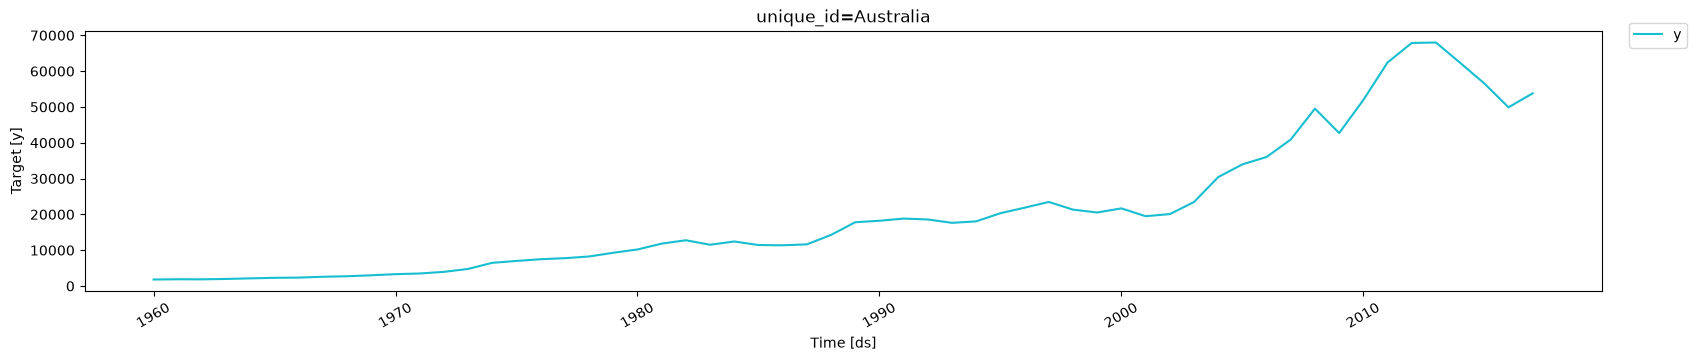

In [3]:
global_economy = pd.read_csv("C:\\Users\\dell\\forecasting\\global_economy.csv")

df = (global_economy.loc[lambda x: x["unique_id"] == "Australia"].assign(y=lambda x: x["GDP"] / x["Population"]))
plot_series(df)

## chapter 3.2

**STL decomposition method = Seasonal and Trend decomposition using LOESS**

**Additive Decomposition** : 

$$
y_t = S_t + T_t + R_t
$$

> where $y_t$​ is the data, $S_t$​ is the seasonal component, $T_t$​ is the trend-cycle component, and $R_t$​ is the remainder component, all at period t

> the additive decomposition is the most appropriate if the magnitude of the seasonal fluctuations, or the variation around the trend-cycle, does not vary with the level of the time series

---

**multiplicative Decomposition** : 

$$
y_t = S_t \times T_t \times R_t
$$

> کی استفاده می‌شود؟ وقتی هرچه سطح داده‌ها بالا می‌رود، نوسان‌ها و قله‌های فصلی هم بزرگ‌تر و کشیده‌تر می‌شوند (متناسب با سطح داده رشد می‌کنند).

---
**اول داده را لگاریتم بگیر، بعد مدل ساده‌ی جمعی را روی آن پیاده کن!**

$$
y_t = S_t \times T_t \times R_t  \text{ is equivalent to } \log(y_t) = \log(S_t) + \log(T_t) + \log(R_t)
$$

In [6]:
us_employment = pd.read_csv("C:\\Users\\dell\\forecasting\\us_employment.csv" , parse_dates=["ds"])
us_employment

,ds,unique_id,y
0,1939-01-01,Total Private,25338.0
1,1939-02-01,Total Private,25447.0
2,1939-03-01,Total Private,25833.0
3,1939-04-01,Total Private,25801.0
4,1939-05-01,Total Private,26113.0
...,...,...,...
143407,2019-05-01,"All Employees, Temporary Help Services",3009.5
143408,2019-06-01,"All Employees, Temporary Help Services",3025.7
143409,2019-07-01,"All Employees, Temporary Help Services",2965.9
143410,2019-08-01,"All Employees, Temporary Help Services",3040.0


In [8]:
us_employment["unique_id"].unique()

array(['Total Private', 'Goods-Producing', 'Private Service-Providing',
       'Mining and Logging', 'Mining and Logging: Logging',
       'Mining and Logging: Mining',
       'Mining and Logging: Oil and Gas Extraction',
       'Mining and Logging: Mining, Except Oil and Gas',
       'Mining and Logging: Coal Mining',
       'Mining and Logging: Support Activities for Mining',
       'Construction', 'Construction: Construction of Buildings',
       'Construction: Residential Building',
       'Construction: Nonresidential Building',
       'Construction: Heavy and Civil Engineering Construction',
       'Construction: Specialty Trade Contractors',
       'Construction: Residential Specialty Trade Contractors',
       'Construction: Nonresidential Specialty Trade Contractors',
       'Manufacturing', 'Durable Goods', 'Durable Goods: Wood Products',
       'Durable Goods: Nonmetallic Mineral Products',
       'Durable Goods: Primary Metals',
       'Durable Goods: Fabricated Metal Produ

In [7]:
us_retail_employment = us_employment.loc[lambda x: (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")]
us_retail_employment

,ds,unique_id,y
50031,1990-01-01,Retail Trade,13255.8
50032,1990-02-01,Retail Trade,12966.3
50033,1990-03-01,Retail Trade,12938.2
50034,1990-04-01,Retail Trade,13012.3
50035,1990-05-01,Retail Trade,13108.3
...,...,...,...
50383,2019-05-01,Retail Trade,15691.6
50384,2019-06-01,Retail Trade,15775.5
50385,2019-07-01,Retail Trade,15785.9
50386,2019-08-01,Retail Trade,15749.5


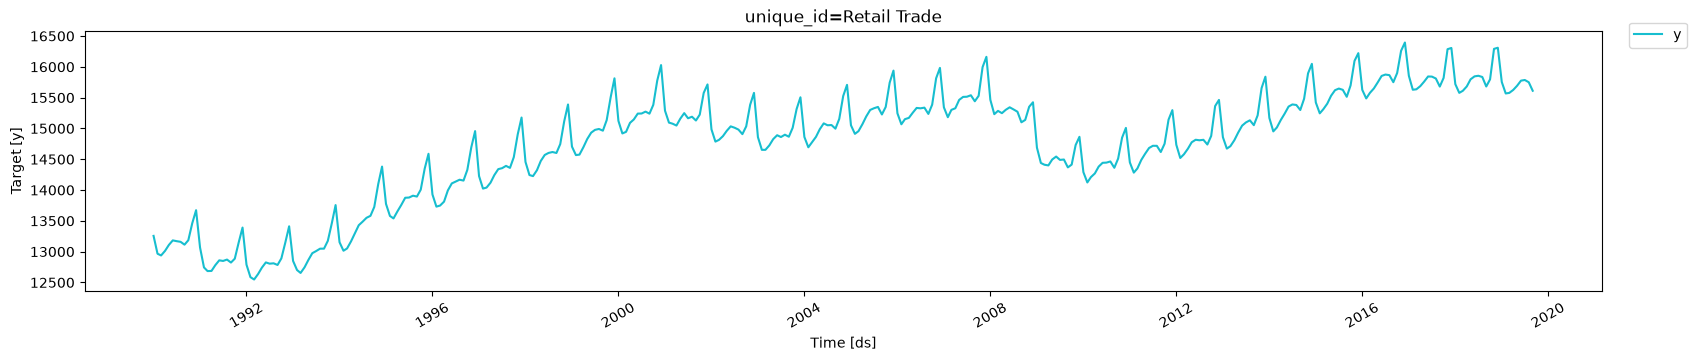

In [ ]:
plot_series(us_retail_employment)